In [1]:
# Biogeme
from bio_estimation_fcns import estimate_mnl, simulate_mnl, estimate_mxl, simulate_mxl, print_results, plot_distributions
import biogeme.biogeme as bio
import biogeme.database as db
from biogeme import models
import biogeme.biogeme_logging as blog
from biogeme.expressions import Beta, Variable, exp, bioDraws

# General python packages
import importlib   
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from pathlib import Path
import os

# Pandas setting to show all columns when displaying a pandas dataframe
pd.set_option('display.max_columns', None)

In [2]:
# Initialize the logger, if it has not been initialized yet
try:
    logger
except NameError:    
    logger = blog.get_screen_logger(level=blog.INFO)
    print('Logger has been initialised')

Logger has been initialised


#### Load the data

In [3]:
data_path =  Path(os.getcwd()) / 'data'
print(data_path)

/Users/sandervancranenburgh/Documents/Repos_and_data/CVDCM_mac/CVDCM_cycling_project_koichi/data


In [4]:
# Load the data as a pandas dataframe
df = pd.read_csv(data_path / 'merged_data.csv')
# df.drop(columns=['prob','Pchosen','LLn'], inplace=True)
df.dropna(inplace=True)
df.shape

(11205, 72)

In [5]:
# Load safety data
df_safety = pd.read_csv(data_path / 'cycling_safety_scores.csv')
df_safety

,image_name,safety_score
0,WE6MEJCD.jpg,0.484000
1,WE6HF9A4.jpg,-1.229883
2,WE6NO1A0.jpg,0.206098
3,WE6MD0C4.jpg,0.859421
4,WE6MDLDV.jpg,-1.066132
...,...,...
6714,WE6J7L7J.jpg,-0.591384
6715,WE6KRIRL.jpg,-0.320186
6716,WE6RCDAK.jpg,1.780707
6717,WE6JK448.jpg,0.598204


In [6]:
# Merge safety scores into the main dataframe
df = df.merge(df_safety, how='left', left_on='IMG1', right_on='image_name')
df.rename(columns={'safety_score': 'SAFETY1'}, inplace=True)
df.drop(columns=['image_name'], inplace=True)
df = df.merge(df_safety, how='left', left_on='IMG2', right_on='image_name')
df.rename(columns={'safety_score': 'SAFETY2'}, inplace=True)
df.drop(columns=['image_name'], inplace=True)

In [7]:
df['RID'].groupby(df['RID']).count().value_counts()

RID
15    747
Name: count, dtype: int64

#### Ensure fixed number of observations per individual

In [8]:
df = df[df["RID"].map(df["RID"].value_counts()) <= 15]
df.shape

(11205, 74)

In [9]:
# Drop RIDs with less than 15 observations
min_obs = 15
print(f'Dropping {df[df["RID"].map(df["RID"].value_counts()) < min_obs]["RID"].nunique()} RIDs with less than {min_obs} observations')
df = df[df["RID"].map(df["RID"].value_counts()) <= min_obs]
print(df['RID'].value_counts().value_counts())
df.shape

Dropping 0 RIDs with less than 15 observations
count
15    747
Name: count, dtype: int64


(11205, 74)

In [10]:
df.columns

Index(['ID', 'RID', 'SEQ', 'train', 'test', 'TL1', 'TT1', 'IMG1', 'TL2', 'TT2',
       'IMG2', 'CHOICE', 'respondent_id', 'set_id', 'age', 'gender',
       'household_composition', 'household_size', 'education', 'income',
       'bills', 'transportation', 'car', 'traveltime', 'commutingdays',
       'cycler', 'cyclingincident', 'cyclinglike', 'cyclingunsafe', 'biketype',
       'trippurpose', 'SAFETY_SCORE1', 'SAFETY_SCORE2', 'Bike_Lane_1',
       'Bike_Lane_2', 'Curb_1', 'Curb_2', 'Pole_1', 'Pole_2', 'Sidewalk_1',
       'Sidewalk_2', 'Sky_1', 'Sky_2', 'Terrain_1', 'Terrain_2',
       'Traffic_Sign_(Front)_1', 'Traffic_Sign_(Front)_2', 'Truck_1',
       'Truck_2', 'Utility_Pole_1', 'Utility_Pole_2', 'Vegetation_1',
       'Vegetation_2', 'Water_1', 'Water_2', 'age_cat', 'gender_cat',
       'household_composition_cat', 'household_size_cat', 'education_cat',
       'income_cat', 'bills_cat', 'transportation_cat', 'car_cat',
       'traveltime_cat', 'commutingdays_cat', 'cycler_cat',
  

In [11]:
# Columns to rename: removing "_"
col_1 = ['Bike_Lane_1','Curb_1','Pole_1','Sidewalk_1','Sky_1','Terrain_1','Traffic_Sign_(Front)_1','Truck_1','Utility_Pole_1','Vegetation_1','Water_1']
col_2 = ['Bike_Lane_2','Curb_2','Pole_2','Sidewalk_2','Sky_2','Terrain_2','Traffic_Sign_(Front)_2','Truck_2','Utility_Pole_2','Vegetation_2','Water_2']
col_new_1 = [c.replace('_','') for c in col_1]
col_new_2 = [c.replace('_','') for c in col_2]
col = col_1 + col_2
df.rename(columns={c: c.replace('_','') for c in col}, inplace=True)

print(col_new_1)
print(col_new_2)

['BikeLane1', 'Curb1', 'Pole1', 'Sidewalk1', 'Sky1', 'Terrain1', 'TrafficSign(Front)1', 'Truck1', 'UtilityPole1', 'Vegetation1', 'Water1']
['BikeLane2', 'Curb2', 'Pole2', 'Sidewalk2', 'Sky2', 'Terrain2', 'TrafficSign(Front)2', 'Truck2', 'UtilityPole2', 'Vegetation2', 'Water2']


In [12]:
df.age.value_counts().sort_index()

age
1    2250
2    2505
3    2940
4    2505
5    1005
Name: count, dtype: int64

In [13]:
covariates =['age']

## MNL

In [14]:
# Create a Biogeme database from the pandas dataframe
attributes = ['RID',
              'TL1','TT1','SAFETY1',
              'TL2','TT2','SAFETY2',
              'CHOICE'] + col_new_1 + col_new_2 + covariates
biodata_mnl_train = db.Database('cycling_project_roos', df[attributes]) ## HACK TO ESTIMATE ON FULL DATASET


In [15]:
# Check for missing values in the attributes used for estimation
df[attributes].isna().sum().sum()

np.int64(0)

In [16]:
# Create biogeme variables
for c in attributes:
    globals()[c] = biodata_mnl_train.variables[c]

In [17]:
# Give a name to the model    
model_name = 'Linear-additive RUM-MNL with safety'

B_TL = Beta('B_TL', 0, None, None, 0)
B_TT = Beta('B_TT', 0, None, None, 0)
B_SAFETY = Beta('B_SAFETY', 1, None, None, 0)

# Utility functions
V1 = B_TL * TL1 + B_TT * TT1 + B_SAFETY * SAFETY1
V2 = B_TL * TL2 + B_TT * TT2 + B_SAFETY * SAFETY2

# Associate utility functions with the numbering of alternatives
V  = {1: V1, 2: V2}

# Associate the availability conditions with the alternatives
AV = {1: 1, 2: 1}

# Estimate the model
results = estimate_mnl(V,AV,CHOICE,biodata_mnl_train,model_name)

print_results(results)  

Biogeme parameters read from biogeme.toml. 
As the model is not too complex, we activate the calculation of second derivatives. If you want to change it, change the name of the algorithm in the TOML file from "automatic" to "simple_bounds" 
As the model is not too complex, we activate the calculation of second derivatives. If you want to change it, change the name of the algorithm in the TOML file from "automatic" to "simple_bounds" 
Optimization algorithm: hybrid Newton/BFGS with simple bounds [simple_bounds] 
** Optimization: Newton with trust region for simple bounds 
Iter.        B_SAFETY            B_TL            B_TT     Function    Relgrad   Radius      Rho      
    0          0.4197         -0.2838         -0.1617      7298.54    0.04349    1.000   0.8715    + 
    1          0.5561         -0.2657         -0.1533      7278.45  0.0005031    10.00    1.007   ++ 
    2          0.5561         -0.2657         -0.1533      7278.45  4.311e-07    10.00    1.001   ++ 




Results for model Linear-additive RUM-MNL with safety
Nbr of parameters:		3
Sample size:			11205
Excluded data:			0
Null log likelihood:		-7766.714
Final log likelihood:		-7278.443
Likelihood ratio test (null):		976.5429
Rho square (null):			0.0629
Rho bar square (null):			0.0625
Akaike Information Criterion:	14562.89
Bayesian Information Criterion:	14584.86

           Value  Rob. Std err  Rob. t-test  Rob. p-value
B_SAFETY  0.5589        0.0255        21.92           0.0
B_TL     -0.2664        0.0157       -17.00           0.0
B_TT     -0.1537        0.0078       -19.76           0.0


In [18]:
# Give a name to the model    
model_name = 'Linear-additive RUM-MNL with safety and age interaction'

B_TL = Beta('B_TL', 0, None, None, 0)
B_TT = Beta('B_TT', 0, None, None, 0)
B_SAFETY_agebase = Beta('B_SAFETY_agebase', 1, None, None, 0)
B_SAFETY_age_61_75 = Beta('B_SAFETY_age_61_75', 1, None, None, 0)

# Utility functions
V1 = B_TL * TL1 + B_TT * TT1 + ((age==5) * B_SAFETY_age_61_75 * SAFETY1 + (age!=5) * B_SAFETY_agebase * SAFETY1)
V2 = B_TL * TL2 + B_TT * TT2 + ((age==5) * B_SAFETY_age_61_75 * SAFETY2 + (age!=5) * B_SAFETY_agebase * SAFETY2)

# Associate utility functions with the numbering of alternatives
V  = {1: V1, 2: V2}

# Associate the availability conditions with the alternatives
AV = {1: 1, 2: 1}

# Estimate the model
results = estimate_mnl(V,AV,CHOICE,biodata_mnl_train,model_name)

print_results(results)  

Biogeme parameters read from biogeme.toml. 
As the model is not too complex, we activate the calculation of second derivatives. If you want to change it, change the name of the algorithm in the TOML file from "automatic" to "simple_bounds" 
As the model is not too complex, we activate the calculation of second derivatives. If you want to change it, change the name of the algorithm in the TOML file from "automatic" to "simple_bounds" 
Optimization algorithm: hybrid Newton/BFGS with simple bounds [simple_bounds] 
** Optimization: Newton with trust region for simple bounds 
Iter. B_SAFETY_age_61 B_SAFETY_agebas            B_TL            B_TT     Function    Relgrad   Radius      Rho      
    0          0.7952          0.3832         -0.2838         -0.1616      7293.53    0.04373    1.000   0.8678    + 
    1          0.8546          0.5302         -0.2659         -0.1533      7272.04  0.0004862    10.00    1.007   ++ 
    2          0.8546          0.5302         -0.2659         -0.153



Results for model Linear-additive RUM-MNL with safety and age interaction
Nbr of parameters:		4
Sample size:			11205
Excluded data:			0
Null log likelihood:		-7766.714
Final log likelihood:		-7272.032
Likelihood ratio test (null):		989.3652
Rho square (null):			0.0637
Rho bar square (null):			0.0632
Akaike Information Criterion:	14552.06
Bayesian Information Criterion:	14581.36

                     Value  Rob. Std err  Rob. t-test  Rob. p-value
B_SAFETY_age_61_75  0.8561        0.0887         9.65           0.0
B_SAFETY_agebase    0.5331        0.0264        20.21           0.0
B_TL               -0.2668        0.0157       -17.02           0.0
B_TT               -0.1538        0.0078       -19.75           0.0


## Mixed Logit

In [19]:
# Tell Biogeme which variable is the identifier of the individuals
biodata_mnl_train.panel('RID')

# Calculate the number of observations per individual
obs_per_ind = biodata_mnl_train.data['RID'].value_counts().unique()[0]
print(f'Number of observations per individual: {obs_per_ind}')

# Use biogeme's "generateFlatPanelDataFrame to create a wide database in which each row corresponds to one individual
df_wide = biodata_mnl_train.generate_flat_panel_dataframe(identical_columns=None)

# Rename the columns, such that they run from columnname_{0} to columnname_{n} 
renumbered_columns = {col: f'{col.split("_")[1]}_{int(col.split("_")[0])-1}' if len(col.split("_")) == 2 else col for col in df_wide.columns}

# Rename the columns using the dictionary
df_wide.rename(columns=renumbered_columns, inplace=True)

# Create Biogeme database object
biodata_wide_train = db.Database('biodata_mnl_train_wide', df_wide)

# Show the first rows of the wide database
print(f'The wide dataset has a shape of {biodata_wide_train.data.shape}')
biodata_wide_train.data.head()

Number of observations per individual: 15
The wide dataset has a shape of (747, 436)


,age,BikeLane1_0,BikeLane2_0,CHOICE_0,Curb1_0,Curb2_0,Pole1_0,Pole2_0,SAFETY1_0,SAFETY2_0,Sidewalk1_0,Sidewalk2_0,Sky1_0,Sky2_0,TL1_0,TL2_0,TT1_0,TT2_0,Terrain1_0,Terrain2_0,TrafficSign(Front)1_0,TrafficSign(Front)2_0,Truck1_0,Truck2_0,UtilityPole1_0,UtilityPole2_0,Vegetation1_0,Vegetation2_0,Water1_0,Water2_0,BikeLane1_1,BikeLane2_1,CHOICE_1,Curb1_1,Curb2_1,Pole1_1,Pole2_1,SAFETY1_1,SAFETY2_1,Sidewalk1_1,Sidewalk2_1,Sky1_1,Sky2_1,TL1_1,TL2_1,TT1_1,TT2_1,Terrain1_1,Terrain2_1,TrafficSign(Front)1_1,TrafficSign(Front)2_1,Truck1_1,Truck2_1,UtilityPole1_1,UtilityPole2_1,Vegetation1_1,Vegetation2_1,Water1_1,Water2_1,BikeLane1_2,BikeLane2_2,CHOICE_2,Curb1_2,Curb2_2,Pole1_2,Pole2_2,SAFETY1_2,SAFETY2_2,Sidewalk1_2,Sidewalk2_2,Sky1_2,Sky2_2,TL1_2,TL2_2,TT1_2,TT2_2,Terrain1_2,Terrain2_2,TrafficSign(Front)1_2,TrafficSign(Front)2_2,Truck1_2,Truck2_2,UtilityPole1_2,UtilityPole2_2,Vegetation1_2,Vegetation2_2,Water1_2,Water2_2,BikeLane1_3,BikeLane2_3,CHOICE_3,Curb1_3,Curb2_3,Pole1_3,Pole2_3,SAFETY1_3,SAFETY2_3,Sidewalk1_3,Sidewalk2_3,Sky1_3,Sky2_3,TL1_3,TL2_3,TT1_3,TT2_3,Terrain1_3,Terrain2_3,TrafficSign(Front)1_3,TrafficSign(Front)2_3,Truck1_3,Truck2_3,UtilityPole1_3,UtilityPole2_3,Vegetation1_3,Vegetation2_3,Water1_3,Water2_3,BikeLane1_4,BikeLane2_4,CHOICE_4,Curb1_4,Curb2_4,Pole1_4,Pole2_4,SAFETY1_4,SAFETY2_4,Sidewalk1_4,Sidewalk2_4,Sky1_4,Sky2_4,TL1_4,TL2_4,TT1_4,TT2_4,Terrain1_4,Terrain2_4,TrafficSign(Front)1_4,TrafficSign(Front)2_4,Truck1_4,Truck2_4,UtilityPole1_4,UtilityPole2_4,Vegetation1_4,Vegetation2_4,Water1_4,Water2_4,BikeLane1_5,BikeLane2_5,CHOICE_5,Curb1_5,Curb2_5,Pole1_5,Pole2_5,SAFETY1_5,SAFETY2_5,Sidewalk1_5,Sidewalk2_5,Sky1_5,Sky2_5,TL1_5,TL2_5,TT1_5,TT2_5,Terrain1_5,Terrain2_5,TrafficSign(Front)1_5,TrafficSign(Front)2_5,Truck1_5,Truck2_5,UtilityPole1_5,UtilityPole2_5,Vegetation1_5,Vegetation2_5,Water1_5,Water2_5,BikeLane1_6,BikeLane2_6,CHOICE_6,Curb1_6,Curb2_6,Pole1_6,Pole2_6,SAFETY1_6,SAFETY2_6,Sidewalk1_6,Sidewalk2_6,Sky1_6,Sky2_6,TL1_6,TL2_6,TT1_6,TT2_6,Terrain1_6,Terrain2_6,TrafficSign(Front)1_6,TrafficSign(Front)2_6,Truck1_6,Truck2_6,UtilityPole1_6,UtilityPole2_6,Vegetation1_6,Vegetation2_6,Water1_6,Water2_6,BikeLane1_7,BikeLane2_7,CHOICE_7,Curb1_7,Curb2_7,Pole1_7,Pole2_7,SAFETY1_7,SAFETY2_7,Sidewalk1_7,Sidewalk2_7,Sky1_7,Sky2_7,TL1_7,TL2_7,TT1_7,TT2_7,Terrain1_7,Terrain2_7,TrafficSign(Front)1_7,TrafficSign(Front)2_7,Truck1_7,Truck2_7,UtilityPole1_7,UtilityPole2_7,Vegetation1_7,Vegetation2_7,Water1_7,Water2_7,BikeLane1_8,BikeLane2_8,CHOICE_8,Curb1_8,Curb2_8,Pole1_8,Pole2_8,SAFETY1_8,SAFETY2_8,Sidewalk1_8,Sidewalk2_8,Sky1_8,Sky2_8,TL1_8,TL2_8,TT1_8,TT2_8,Terrain1_8,Terrain2_8,TrafficSign(Front)1_8,TrafficSign(Front)2_8,Truck1_8,Truck2_8,UtilityPole1_8,UtilityPole2_8,Vegetation1_8,Vegetation2_8,Water1_8,Water2_8,BikeLane1_9,BikeLane2_9,CHOICE_9,Curb1_9,Curb2_9,Pole1_9,Pole2_9,SAFETY1_9,SAFETY2_9,Sidewalk1_9,Sidewalk2_9,Sky1_9,Sky2_9,TL1_9,TL2_9,TT1_9,TT2_9,Terrain1_9,Terrain2_9,TrafficSign(Front)1_9,TrafficSign(Front)2_9,Truck1_9,Truck2_9,UtilityPole1_9,UtilityPole2_9,Vegetation1_9,Vegetation2_9,Water1_9,Water2_9,BikeLane1_10,BikeLane2_10,CHOICE_10,Curb1_10,Curb2_10,Pole1_10,Pole2_10,SAFETY1_10,SAFETY2_10,Sidewalk1_10,Sidewalk2_10,Sky1_10,Sky2_10,TL1_10,TL2_10,TT1_10,TT2_10,Terrain1_10,Terrain2_10,TrafficSign(Front)1_10,TrafficSign(Front)2_10,Truck1_10,Truck2_10,UtilityPole1_10,UtilityPole2_10,Vegetation1_10,Vegetation2_10,Water1_10,Water2_10,BikeLane1_11,BikeLane2_11,CHOICE_11,Curb1_11,Curb2_11,Pole1_11,Pole2_11,SAFETY1_11,SAFETY2_11,Sidewalk1_11,Sidewalk2_11,Sky1_11,Sky2_11,TL1_11,TL2_11,TT1_11,TT2_11,Terrain1_11,Terrain2_11,TrafficSign(Front)1_11,TrafficSign(Front)2_11,Truck1_11,Truck2_11,UtilityPole1_11,UtilityPole2_11,Vegetation1_11,Vegetation2_11,Water1_11,Water2_11,BikeLane1_12,BikeLane2_12,CHOICE_12,Curb1_12,Curb2_12,Pole1_12,Pole2_12,SAFETY1_12,SAFETY2_12,Sidewalk1_12,Sidewalk2_12,Sky1_12,Sky2_12,TL1_12,TL2_12,TT1_12,TT2_12,Terrain1_12,Terrain2_12,TrafficSign(Front)1_12,TrafficSign(Front)2_12,Truck1_12,Truck2_12

In [20]:
for att in df.columns:
    if att != 'RID' and att != 'age':
        globals()[att] = {q: Variable(f'{att}_{q}')     for q in range(obs_per_ind)}

# Create biogeme variables
for c in covariates:
    globals()[c] = biodata_wide_train.variables[c]

### Mixed Logit with Log-Normal Distributions

In [ ]:
# Give the model a name
model_name = 'Panel MXL with log-normally distributed parameters'

# Parameters definition enabling the construction of random parameters
B_TT     = Beta('B_TT',      -1, None, None, 0)
B_TL     = Beta('B_TL',      -1, None, None, 0)
B_SAFETY = Beta('B_SAFETY',  -3, None, None, 0)
sigma_TT = Beta('sigma_TT',  0.1, None, None, 0)
sigma_TL = Beta('sigma_TL',  0.1, None, None, 0)
sigma_SAFETY = Beta('sigma_SAFETY', 0.1, None, None, 0)

# Construction of random parameters
B_TT_rnd  = -exp(B_TT + sigma_TT * bioDraws('B_TT_rnd', 'NORMAL_HALTON2')) # Note the negative sign for TT and TL
B_TL_rnd  = -exp(B_TL + sigma_TL * bioDraws('B_TL_rnd', 'NORMAL_HALTON2'))
B_SAFETY_rnd = exp(B_SAFETY + sigma_SAFETY * bioDraws('B_SAFETY_rnd', 'NORMAL_HALTON2')) # Note the positive sign for Vimg

# Definition of the utility functions
V1 = [B_TL_rnd * TL1[q] + B_TT_rnd * TT1[q] + B_SAFETY_rnd * SAFETY1[q] for q in range(obs_per_ind)]
V2 = [B_TL_rnd * TL2[q] + B_TT_rnd * TT2[q] + B_SAFETY_rnd * SAFETY2[q] for q in range(obs_per_ind)]

# Create a dictionary to list the utility functions with the numbering of alternatives
V = [{1: V1[q], 2: V2[q]} for q in range(obs_per_ind)]
           
# Create a dictionary to describe the availability conditions of each alternative
AV = {1:1, 2:1}

# Specify the number of draws for the Monte Carlo integration
num_draws = 500

# Estimate the model
results = estimate_mxl(V,AV,"CHOICE",obs_per_ind,num_draws, biodata_wide_train, model_name) 

print_results(results)

Biogeme parameters read from biogeme.toml. 
As the model is rather complex, we cancel the calculation of second derivatives. If you want to control the parameters, change the name of the algorithm in the TOML file from "automatic" to "simple_bounds" 
The number of draws (50) is low. The results may not be meaningful. 
As the model is rather complex, we cancel the calculation of second derivatives. If you want to control the parameters, change the name of the algorithm in the TOML file from "automatic" to "simple_bounds" 
Optimization algorithm: hybrid Newton/BFGS with simple bounds [simple_bounds] 
** Optimization: BFGS with trust region for simple bounds 
Iter.        B_SAFETY            B_TL            B_TT    sigma_SAFETY        sigma_TL        sigma_TT     Function    Relgrad   Radius      Rho      
    0          -2.000          -2.000          -2.000         -0.9000           1.100           1.100      7018.99    0.03544    1.000   0.4562    + 
    1          -2.000          -2.0



Results for model Panel MXL with log-normally distributed parameters
Nbr of parameters:		6
Sample size:			747
Excluded data:			0
Null log likelihood:		-7766.714
Final log likelihood:		-6793.267
Likelihood ratio test (null):		1946.894
Rho square (null):			0.125
Rho bar square (null):			0.125
Akaike Information Criterion:	13598.53
Bayesian Information Criterion:	13626.23

               Value  Rob. Std err  Rob. t-test  Rob. p-value
B_SAFETY     -0.5636        0.0721        -7.82           0.0
B_TL         -1.8317        0.2609        -7.02           0.0
B_TT         -2.9404        0.2951        -9.96           0.0
sigma_SAFETY -0.3703        0.1025        -3.61           0.0
sigma_TL      1.7755        0.2889         6.15           0.0
sigma_TT      2.4790        0.3456         7.17           0.0


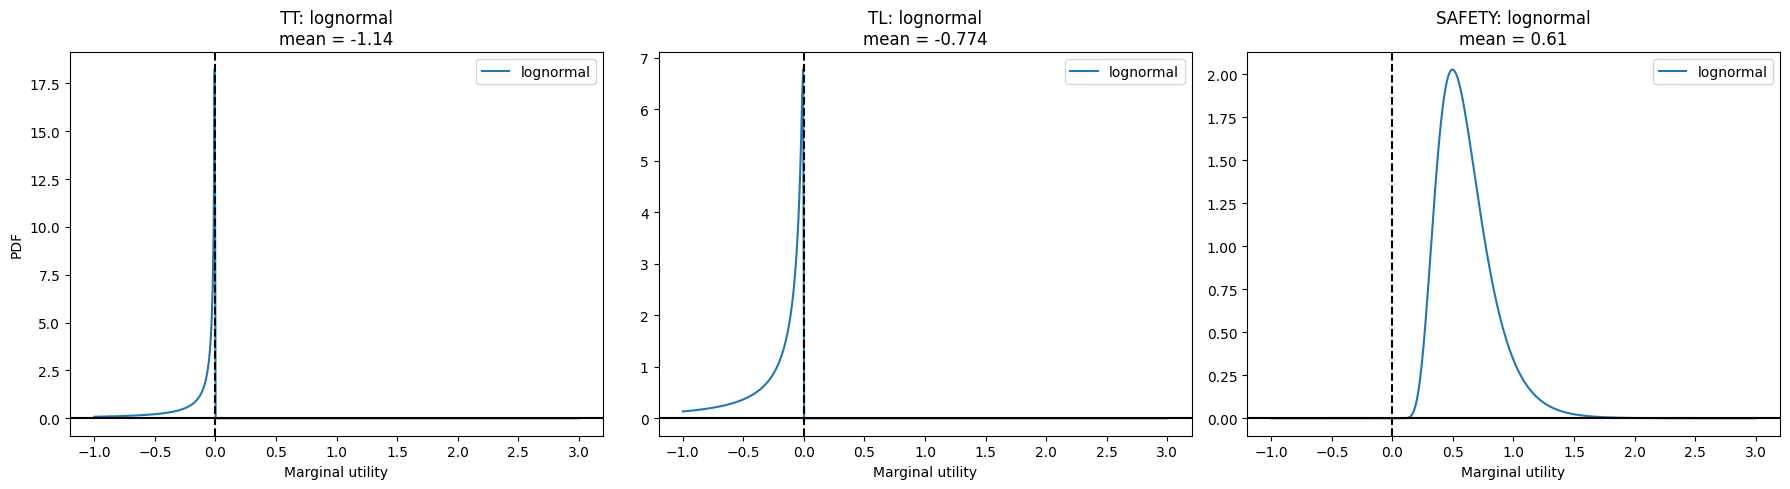

In [22]:
# Specify the distribution types for each part of the utility function
distr_types = {
    'TT':  {'dist': 'lognormal', 'sign': -1},
    'TL':  {'dist': 'lognormal', 'sign': -1},
    'SAFETY': {'dist': 'lognormal', 'sign': 1}
}
# Plot the distributions of the random parameters
xmin = -1
xmax = 3
plot_distributions(results, distr_types, xmin, xmax)

In [23]:
# Give the model a name
model_name = 'Panel MXL with log-normally distributed parameters with age interaction'

# Parameters definition enabling the construction of random parameters
B_TT     = Beta('B_TT',      -1, None, None, 0)
B_TL     = Beta('B_TL',      -1, None, None, 0)
B_SAFETY_agebase = Beta('B_SAFETY_agebase',  -3, None, None, 0)
B_SAFETY_age6175 = Beta('B_SAFETY_age6175',  -3, None, None, 0)
sigma_TT = Beta('sigma_TT',  0.1, None, None, 0)
sigma_TL = Beta('sigma_TL',  0.1, None, None, 0)
sigma_SAFETY_agebase = Beta('sigma_SAFETY_agebase', 0.1, None, None, 0)
sigma_SAFETY_age6175 = Beta('sigma_SAFETY_age6175', 0.1, None, None, 0)

# Construction of random parameters
B_TT_rnd  = -exp(B_TT + sigma_TT * bioDraws('B_TT_rnd', 'NORMAL_HALTON2')) 
B_TL_rnd  = -exp(B_TL + sigma_TL * bioDraws('B_TL_rnd', 'NORMAL_HALTON2'))
B_SAFETY_agebase_rnd = exp(B_SAFETY_agebase + sigma_SAFETY_agebase * bioDraws('B_SAFETY_agebase_rnd', 'NORMAL_HALTON2')) # Note the positive sign for Vimg
B_SAFETY_age6175_rnd = exp(B_SAFETY_age6175 + sigma_SAFETY_age6175 * bioDraws('B_SAFETY_age6175_rnd', 'NORMAL_HALTON2')) # Note the positive sign for Vimg


# Definition of the utility functions
V1 = [B_TL_rnd * TL1[q] + B_TT_rnd * TT1[q] + (B_SAFETY_agebase_rnd + (age == 5) * B_SAFETY_age6175_rnd) * SAFETY1[q] for q in range(obs_per_ind)]
V2 = [B_TL_rnd * TL2[q] + B_TT_rnd * TT2[q] + (B_SAFETY_agebase_rnd + (age == 5) * B_SAFETY_age6175_rnd) * SAFETY2[q] for q in range(obs_per_ind)]

# Create a dictionary to list the utility functions with the numbering of alternatives
V = [{1: V1[q], 2: V2[q]} for q in range(obs_per_ind)]
           
# Create a dictionary to describe the availability conditions of each alternative
AV = {1:1, 2:1}

# Specify the number of draws for the Monte Carlo integration
num_draws = 500

# Estimate the model
results = estimate_mxl(V,AV,"CHOICE",obs_per_ind,num_draws, biodata_wide_train, model_name) 

print_results(results)

Biogeme parameters read from biogeme.toml. 
As the model is rather complex, we cancel the calculation of second derivatives. If you want to control the parameters, change the name of the algorithm in the TOML file from "automatic" to "simple_bounds" 
The number of draws (500) is low. The results may not be meaningful. 
As the model is rather complex, we cancel the calculation of second derivatives. If you want to control the parameters, change the name of the algorithm in the TOML file from "automatic" to "simple_bounds" 
Optimization algorithm: hybrid Newton/BFGS with simple bounds [simple_bounds] 
** Optimization: BFGS with trust region for simple bounds 
Iter. B_SAFETY_age_61 B_SAFETY_agebas            B_TL            B_TT sigma_SAFETY_ag sigma_SAFETY_ag        sigma_TL        sigma_TT     Function    Relgrad   Radius      Rho      
    0          -2.000          -2.000          -2.000          -2.000         -0.9000         -0.9000           1.100           1.100      7000.70    0.



Results for model Panel MXL with log-normally distributed parameters
Nbr of parameters:		8
Sample size:			747
Excluded data:			0
Null log likelihood:		-7766.714
Final log likelihood:		-6790.466
Likelihood ratio test (null):		1952.496
Rho square (null):			0.126
Rho bar square (null):			0.125
Akaike Information Criterion:	13596.93
Bayesian Information Criterion:	13633.86

                         Value  Rob. Std err  Rob. t-test  Rob. p-value
B_SAFETY_age_61_75     -2.2268        0.7564        -2.94          0.00
B_SAFETY_agebase       -0.5788        0.0712        -8.13          0.00
B_TL                   -1.8547        0.2427        -7.64          0.00
B_TT                   -2.9816        0.2749       -10.85          0.00
sigma_SAFETY_age_61_75 -0.9729        0.4522        -2.15          0.03
sigma_SAFETY_agebase   -0.3417        0.1012        -3.38          0.00
sigma_TL                1.7864        0.2826         6.32          0.00
sigma_TT                2.4942        0.2678     

In [25]:
# Give the model a name
model_name = 'Panel MXL with log-normally distributed parameters with age interaction, common sigma'

# Parameters definition enabling the construction of random parameters
B_TT     = Beta('B_TT',      -1, None, None, 0)
B_TL     = Beta('B_TL',      -1, None, None, 0)
B_SAFETY_agebase = Beta('B_SAFETY_agebase',  -3, None, None, 0)
B_SAFETY_age6175 = Beta('B_SAFETY_age6175',  -3, None, None, 0)
sigma_TT = Beta('sigma_TT',  0.1, None, None, 0)
sigma_TL = Beta('sigma_TL',  0.1, None, None, 0)
sigma_SAFETY_agebase = Beta('sigma_SAFETY_agebase', 0.1, None, None, 0)

# Construction of random parameters
B_TT_rnd  = -exp(B_TT + sigma_TT * bioDraws('B_TT_rnd', 'NORMAL_HALTON2')) 
B_TL_rnd  = -exp(B_TL + sigma_TL * bioDraws('B_TL_rnd', 'NORMAL_HALTON2'))
B_SAFETY_agebase_rnd = exp(B_SAFETY_agebase + sigma_SAFETY_agebase * bioDraws('B_SAFETY_agebase_rnd', 'NORMAL_HALTON2')) # Note the positive sign for Vimg
B_SAFETY_age6175_rnd = exp(B_SAFETY_age6175 + sigma_SAFETY_agebase * bioDraws('B_SAFETY_age6175_rnd', 'NORMAL_HALTON2')) # Note the positive sign for Vimg


# Definition of the utility functions
V1 = [B_TL_rnd * TL1[q] + B_TT_rnd * TT1[q] + (B_SAFETY_agebase_rnd + (age == 5) * B_SAFETY_age6175_rnd) * SAFETY1[q] for q in range(obs_per_ind)]
V2 = [B_TL_rnd * TL2[q] + B_TT_rnd * TT2[q] + (B_SAFETY_agebase_rnd + (age == 5) * B_SAFETY_age6175_rnd) * SAFETY2[q] for q in range(obs_per_ind)]

# Create a dictionary to list the utility functions with the numbering of alternatives
V = [{1: V1[q], 2: V2[q]} for q in range(obs_per_ind)]
           
# Create a dictionary to describe the availability conditions of each alternative
AV = {1:1, 2:1}

# Specify the number of draws for the Monte Carlo integration
num_draws = 500

# Estimate the model
results = estimate_mxl(V,AV,"CHOICE",obs_per_ind,num_draws, biodata_wide_train, model_name) 

print_results(results)

Biogeme parameters read from biogeme.toml. 
As the model is rather complex, we cancel the calculation of second derivatives. If you want to control the parameters, change the name of the algorithm in the TOML file from "automatic" to "simple_bounds" 
The number of draws (500) is low. The results may not be meaningful. 
As the model is rather complex, we cancel the calculation of second derivatives. If you want to control the parameters, change the name of the algorithm in the TOML file from "automatic" to "simple_bounds" 
Optimization algorithm: hybrid Newton/BFGS with simple bounds [simple_bounds] 
** Optimization: BFGS with trust region for simple bounds 
Iter. B_SAFETY_age617 B_SAFETY_agebas            B_TL            B_TT sigma_SAFETY_ag        sigma_TL        sigma_TT     Function    Relgrad   Radius      Rho      
    0          -2.000          -2.000          -2.000          -2.000         -0.9000           1.100           1.100      7000.70    0.03200    1.000   0.4617    + 
  



Results for model Panel MXL with log-normally distributed parameters with age interaction, common sigma
Nbr of parameters:		7
Sample size:			747
Excluded data:			0
Null log likelihood:		-7766.714
Final log likelihood:		-6790.887
Likelihood ratio test (null):		1951.655
Rho square (null):			0.126
Rho bar square (null):			0.125
Akaike Information Criterion:	13595.77
Bayesian Information Criterion:	13628.09

                       Value  Rob. Std err  Rob. t-test  Rob. p-value
B_SAFETY_age6175     -1.8644        0.6377        -2.92           0.0
B_SAFETY_agebase     -0.5835        0.0746        -7.83           0.0
B_TL                 -1.8499        0.2433        -7.60           0.0
B_TT                 -2.9766        0.2743       -10.85           0.0
sigma_SAFETY_agebase -0.3554        0.1043        -3.41           0.0
sigma_TL              1.7879        0.2842         6.29           0.0
sigma_TT              2.4975        0.2687         9.29           0.0
